# HP k=20 vs FoldSeek and TEA Comparison

Compare KmerSeek HP k=20 results with FoldSeek and TEA to identify unique relationships.

Goals:
1. Apply TF-IDF threshold to HP k=20 results
2. Compute sensitivity until first false positive for all methods
3. Identify homology relationships that HP k=20 detects but FoldSeek/TEA miss
4. Visualize performance comparisons

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add notebooks directory to path for imports
sys.path.append(str(Path.cwd()))

from scope_kmerseek_utils import (
    add_scope_hierarchical_levels,
    load_rocx_file,
    kmerseek_to_rocx,
    plot_sensitivity_from_rocx,
    compute_auc,
    read_csv_with_size_limit
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load Data

In [2]:
# Paths
hp_k20_path = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv")
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

print("Loading HP k=20 data...")
hp_k20 = read_csv_with_size_limit(hp_k20_path, max_rows=15_000_000, size_threshold_gb=1.0)
print(f"HP k=20 shape: {hp_k20.shape}")
print(f"Columns: {hp_k20.columns}")
hp_k20.head()

Loading HP k=20 data...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv (1.82 GB) - reading first 15,000,000 rows...
HP k=20 shape: (3563401, 30)
Columns: ['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64
"""d2jdii_ a.137.8.1 (I:) automat…","""9217cfbab6dc3533""","""d2o3aa1 c.116.1.8 (A:2-167) Un…","""48a0dfbabc559174""",1.0,6,20,1,"""hp""",0.040816,1.0,1.0,1.0,0.0,0.040816,24.5,45.540609,0.000516,1.6671e-20,1.6671e-20,0.003097,1937.489362,0,25,"""VAYWRQAGLSYIRYSQICAKAVRDA""",100,125,"""VVGAEKVPPEVYELCDLNISIGTQP""","""hhhhpphhhphhphpphphphhpph""",25
"""d2ciob_ b.1.26.0 (B:) automate…","""37546b0af893df46""","""d1eu1a1 b.52.2.2 (A:626-780) D…","""e7741da2767b0728""",1.0,2,20,1,"""hp""",0.014706,1.0,1.0,1.0,0.0,0.014706,68.0,16.077019,0.000329,1.0419e-7,1.0419e-7,0.000659,3035.4,0,21,"""GGTMVLEVKALKAGKHTLSLA""",51,72,"""AARGIADGDVLRVFNDRGQIL""","""hhphhhphphhphhppphphh""",21
"""d2ciob_ b.1.26.0 (B:) automate…","""37546b0af893df46""","""d1to6a_ c.141.1.1 (A:) Glycera…","""4cee2cb73d15ca10""",1.0,2,20,1,"""hp""",0.005682,1.0,1.0,1.0,0.0,0.005682,176.0,16.077019,0.000329,1.0419e-7,1.0419e-7,0.000659,3035.4,0,21,"""GGTMVLEVKALKAGKHTLSLA""",249,270,"""GLCAFAQASIVSGIDTCLDLI""","""hhphhhphphhphhppphphh""",21
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""454913a6d6cec307""","""d1woua_ c.47.1.16 (A:) Putativ…","""b93279ba82a7995b""",1.0,1,20,1,"""hp""",0.01,1.0,1.0,1.0,0.0,0.01,100.0,8.528924,0.000198,0.000198,0.000198,0.000198,5059.0,0,20,"""LSRLERVYQSEQAEKLLLAG""",8,28,"""FEEFHRAVEQHNGKTIFAYF""","""hpphpphhpppphpphhhhh""",20
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""454913a6d6cec307""","""d3t6ec_ a.138.1.2 (C:) Photosy…","""3dc5d55e72784657""",1.0,1,20,1,"""hp""",0.003175,1.0,1.0,1.0,0.0,0.003175,315.0,8.528924,0.000198,0.000198,0.000198,0.000198,5059.0,0,20,"""LSRLERVYQSEQAEKLLLAG""",249,269,"""AQTFESWGKKSTPQRAIAWW""","""hpphpphhpppphpphhhhh""",20


In [3]:
# Add SCOPe hierarchical levels
print("Adding SCOPe hierarchical levels...")
hp_k20 = add_scope_hierarchical_levels(hp_k20)
print(f"After adding levels: {hp_k20.shape}")
hp_k20.head()

Adding SCOPe hierarchical levels...
After adding levels: (3563401, 42)


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_family,query_superfamily,query_fold,query_class,target_family,target_superfamily,target_fold,target_class,family_match,superfamily_match,fold_match,class_match
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str,str,str,str,str,str,str,bool,bool,bool,bool
"""d2jdii_ a.137.8.1 (I:) automat…","""9217cfbab6dc3533""","""d2o3aa1 c.116.1.8 (A:2-167) Un…","""48a0dfbabc559174""",1.0,6,20,1,"""hp""",0.040816,1.0,1.0,1.0,0.0,0.040816,24.5,45.540609,0.000516,1.6671e-20,1.6671e-20,0.003097,1937.489362,0,25,"""VAYWRQAGLSYIRYSQICAKAVRDA""",100,125,"""VVGAEKVPPEVYELCDLNISIGTQP""","""hhhhpphhhphhphpphphphhpph""",25,"""a.137.8.1""","""a.137.8""","""a.137""","""a""","""c.116.1.8""","""c.116.1""","""c.116""","""c""",false,false,false,false
"""d2ciob_ b.1.26.0 (B:) automate…","""37546b0af893df46""","""d1eu1a1 b.52.2.2 (A:626-780) D…","""e7741da2767b0728""",1.0,2,20,1,"""hp""",0.014706,1.0,1.0,1.0,0.0,0.014706,68.0,16.077019,0.000329,1.0419e-7,1.0419e-7,0.000659,3035.4,0,21,"""GGTMVLEVKALKAGKHTLSLA""",51,72,"""AARGIADGDVLRVFNDRGQIL""","""hhphhhphphhphhppphphh""",21,"""b.1.26.0""","""b.1.26""","""b.1""","""b""","""b.52.2.2""","""b.52.2""","""b.52""","""b""",false,false,false,true
"""d2ciob_ b.1.26.0 (B:) automate…","""37546b0af893df46""","""d1to6a_ c.141.1.1 (A:) Glycera…","""4cee2cb73d15ca10""",1.0,2,20,1,"""hp""",0.005682,1.0,1.0,1.0,0.0,0.005682,176.0,16.077019,0.000329,1.0419e-7,1.0419e-7,0.000659,3035.4,0,21,"""GGTMVLEVKALKAGKHTLSLA""",249,270,"""GLCAFAQASIVSGIDTCLDLI""","""hhphhhphphhphhppphphh""",21,"""b.1.26.0""","""b.1.26""","""b.1""","""b""","""c.141.1.1""","""c.141.1""","""c.141""","""c""",false,false,false,false
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""454913a6d6cec307""","""d1woua_ c.47.1.16 (A:) Putativ…","""b93279ba82a7995b""",1.0,1,20,1,"""hp""",0.01,1.0,1.0,1.0,0.0,0.01,100.0,8.528924,0.000198,0.000198,0.000198,0.000198,5059.0,0,20,"""LSRLERVYQSEQAEKLLLAG""",8,28,"""FEEFHRAVEQHNGKTIFAYF""","""hpphpphhpppphpphhhhh""",20,"""c.68.1.0""","""c.68.1""","""c.68""","""c""","""c.47.1.16""","""c.47.1""","""c.47""","""c""",false,false,false,true
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""454913a6d6cec307""","""d3t6ec_ a.138.1.2 (C:) Photosy…","""3dc5d55e72784657""",1.0,1,20,1,"""hp""",0.003175,1.0,1.0,1.0,0.0,0.003175,315.0,8.528924,0.000198,0.000198,0.000198,0.000198,5059.0,0,20,"""LSRLERVYQSEQAEKLLLAG""",249,269,"""AQTFESWGKKSTPQRAIAWW""","""hpphpphhpppphpphhhhh""",20,"""c.68.1.0""","""c.68.1""","""c.68""","""c""","""a.138.1.2""","""a.138.1""","""a.138""","""a""",false,false,false,false


In [4]:
# Load FoldSeek and TEA results
print("Loading FoldSeek rocx...")
foldseek = load_rocx_file(tea_dir / "foldseek.rocx")
print(f"FoldSeek shape: {foldseek.shape}")
print(f"FoldSeek columns: {foldseek.columns}")

print("\nLoading TEA results...")
# TEA file is comma-separated, not tab-separated
tea_all = pl.read_csv(tea_dir / "tea_all.rocx", separator=",")
print(f"TEA all shape: {tea_all.shape}")
print(f"TEA columns: {tea_all.columns}")

foldseek.head()

Loading FoldSeek rocx...
FoldSeek shape: (5713, 9)
FoldSeek columns: ['NAME', 'SCOP', 'FAM', 'SFAM', 'FOLD', 'FP', 'FAMCNT', 'SFAMCNT', 'FOLDCNT']

Loading TEA results...
TEA all shape: (5737, 9)
TEA columns: ['NAME', 'SCOP', 'FAM', 'SFAM', 'FOLD', 'FP', 'FAMCNT', 'SFAMCNT', 'FOLDCNT']


NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.992366,0.0,1,13,143,145
"""d3ctaa2""","""b.43.5.2""",1.0,0.4,0.0,1,2,6,55
"""d2ckxa1""","""a.4.1.3""",0.357143,0.0505051,0.0,1,15,113,425
"""d5r4oa_""","""a.29.2.0""",1.0,0.6,0.0,1,27,31,73
"""d1w5sa1""","""a.4.5.11""",0.666667,0.445783,0.005747,1,4,252,425


## 2. Explore TF-IDF Distribution

TF-IDF statistics:
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 3.563401e6   │
│ null_count ┆ 0.0          │
│ mean       ┆ 2101.526667  │
│ std        ┆ 1323.517682  │
│ min        ┆ 7.835777     │
│ 25%        ┆ 1157.369223  │
│ 50%        ┆ 1910.883966  │
│ 75%        ┆ 2690.489816  │
│ max        ┆ 14162.862377 │
└────────────┴──────────────┘


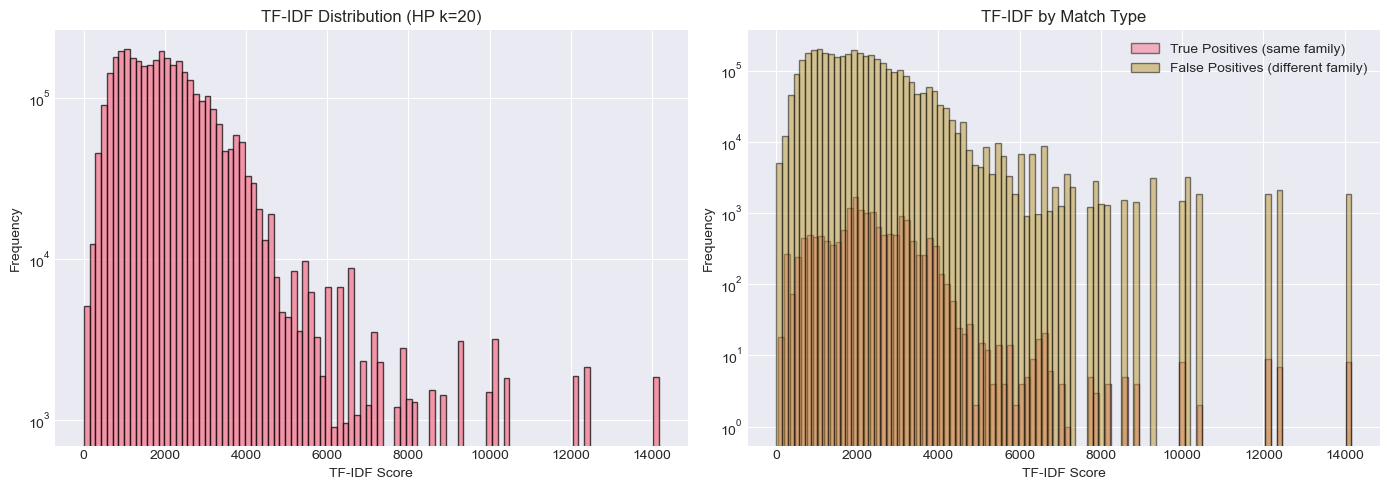


TF-IDF quantiles:
50%: 1910.883966
75%: 2690.489816
90%: 3621.525150
95%: 4187.005247
99%: 6751.266129

ANALYZING FAMILY LEVEL


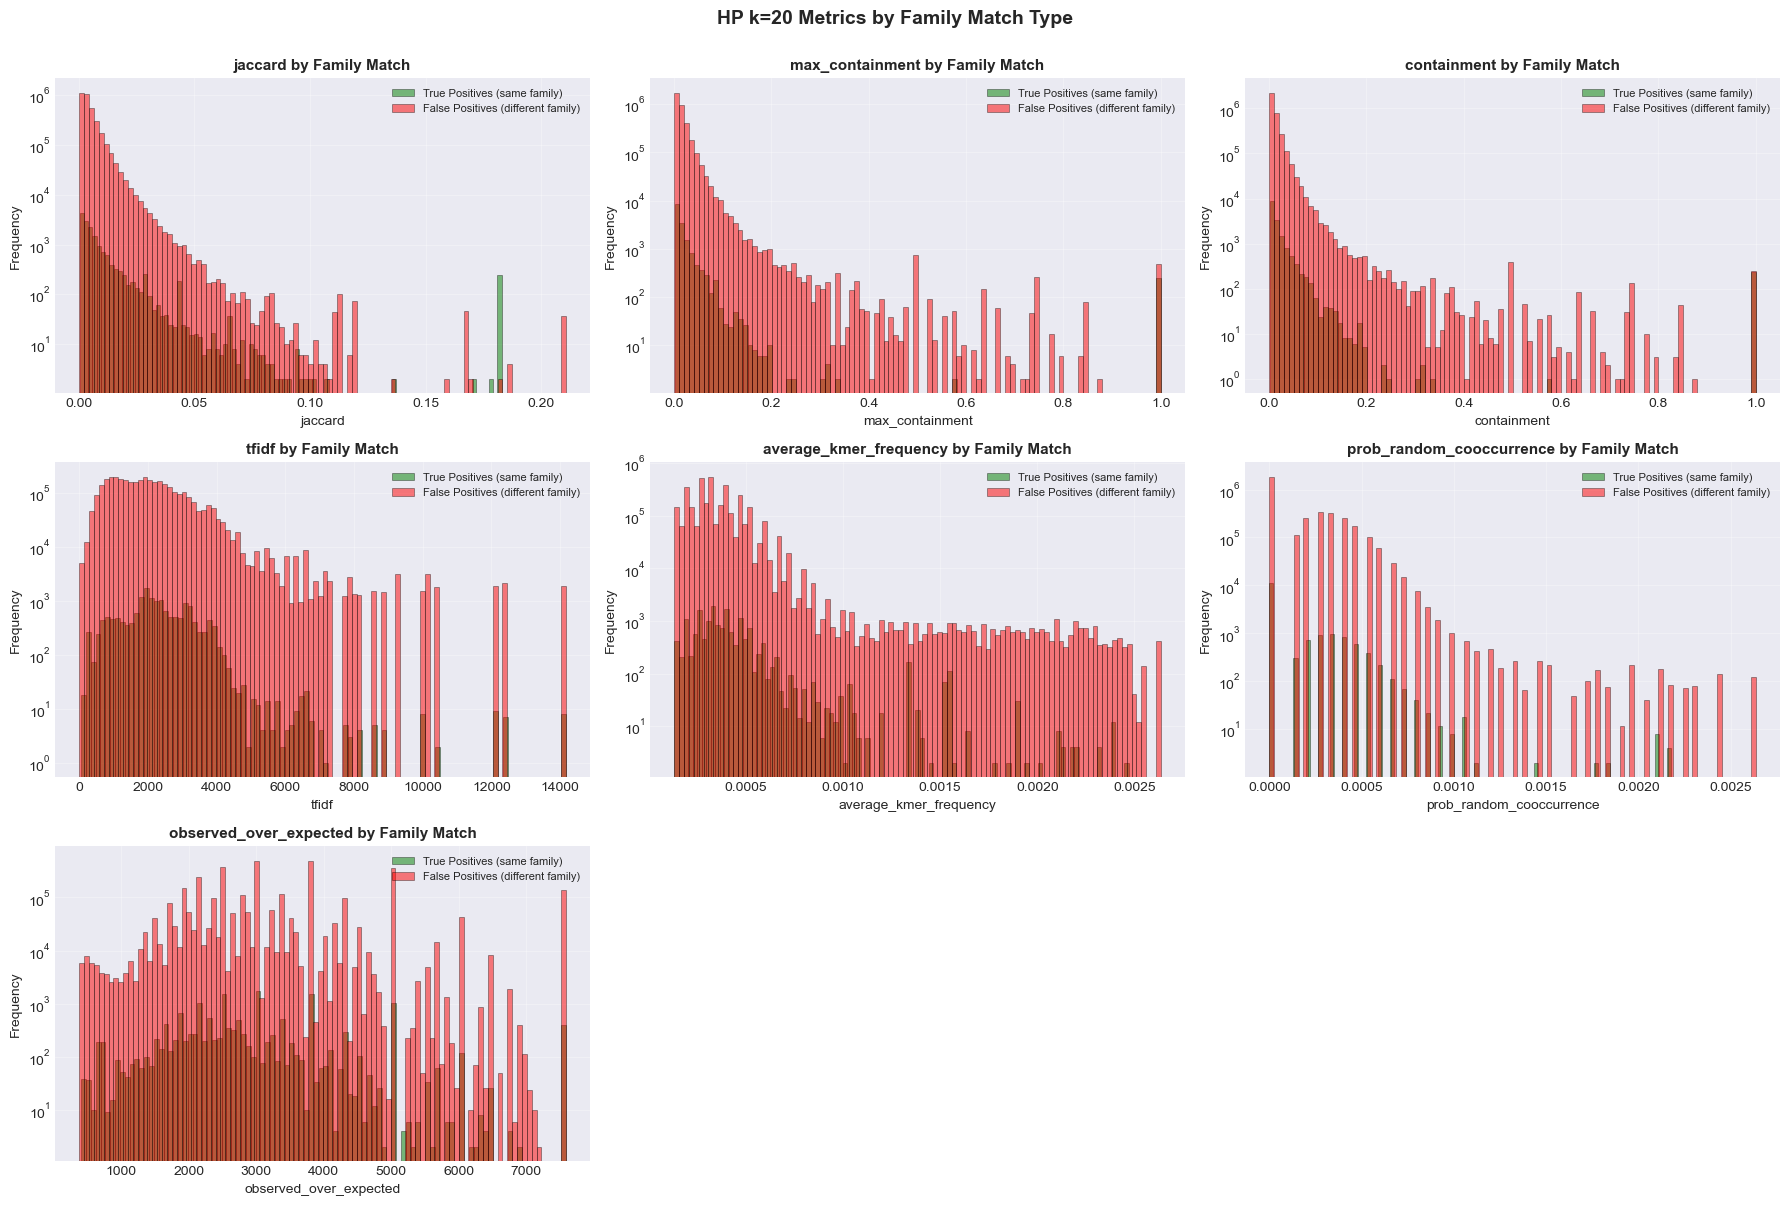


QUANTILES FOR ALL METRICS (Family Match)

jaccard:
  True Positives (same family):
    25%: 0.002304
    50%: 0.004739
    75%: 0.010512
    90%: 0.023095
    95%: 0.035443
    99%: 0.182857
  False Positives (different family):
    25%: 0.002179
    50%: 0.003571
    75%: 0.006270
    90%: 0.010435
    95%: 0.014085
    99%: 0.025000

max_containment:
  True Positives (same family):
    25%: 0.005102
    50%: 0.010323
    75%: 0.022422
    90%: 0.048387
    95%: 0.073529
    99%: 1.000000
  False Positives (different family):
    25%: 0.006536
    50%: 0.010989
    75%: 0.020000
    90%: 0.034483
    95%: 0.048387
    99%: 0.095238

containment:
  True Positives (same family):
    25%: 0.004630
    50%: 0.009569
    75%: 0.021008
    90%: 0.045752
    95%: 0.070175
    99%: 1.000000
  False Positives (different family):
    25%: 0.004348
    50%: 0.007937
    75%: 0.014493
    90%: 0.026022
    95%: 0.037037
    99%: 0.073171

tfidf:
  True Positives (same family):
    25%: 1721.7306

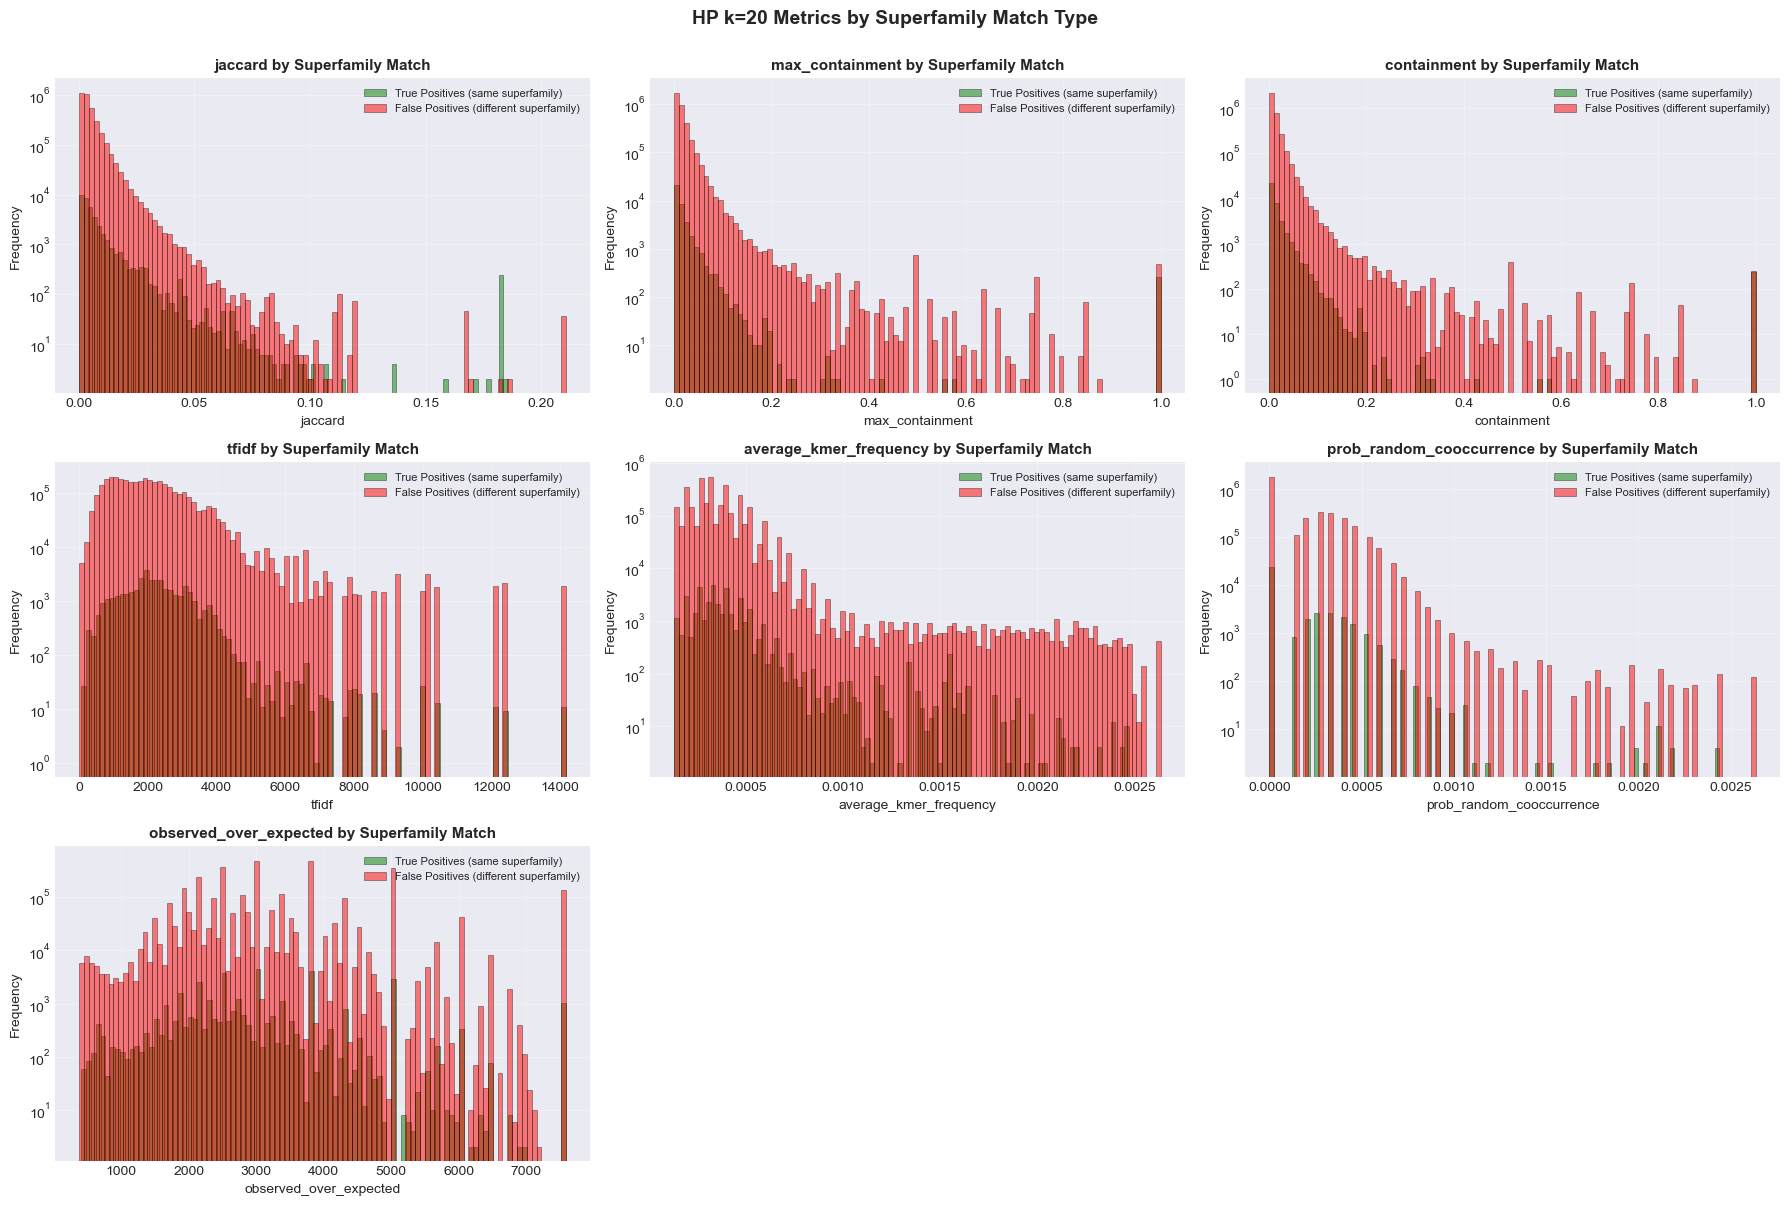


QUANTILES FOR ALL METRICS (Superfamily Match)

jaccard:
  True Positives (same superfamily):
    25%: 0.002222
    50%: 0.004317
    75%: 0.008850
    90%: 0.018519
    95%: 0.028402
    99%: 0.066929
  False Positives (different superfamily):
    25%: 0.002179
    50%: 0.003571
    75%: 0.006250
    90%: 0.010417
    95%: 0.014019
    99%: 0.024793

max_containment:
  True Positives (same superfamily):
    25%: 0.005155
    50%: 0.009740
    75%: 0.019920
    90%: 0.040107
    95%: 0.060606
    99%: 0.147541
  False Positives (different superfamily):
    25%: 0.006536
    50%: 0.010989
    75%: 0.020000
    90%: 0.034483
    95%: 0.048387
    99%: 0.095238

containment:
  True Positives (same superfamily):
    25%: 0.004464
    50%: 0.008696
    75%: 0.018018
    90%: 0.037313
    95%: 0.055825
    99%: 0.132948
  False Positives (different superfamily):
    25%: 0.004348
    50%: 0.007937
    75%: 0.014493
    90%: 0.025974
    95%: 0.037037
    99%: 0.073059

tfidf:
  True Positive

In [5]:
# Check TF-IDF statistics
print("TF-IDF statistics:")
print(hp_k20['tfidf'].describe())

# Plot TF-IDF distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(hp_k20['tfidf'].to_numpy(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('TF-IDF Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('TF-IDF Distribution (HP k=20)')
axes[0].set_yscale('log')

# TF-IDF by match type
tp_tfidf = hp_k20.filter(pl.col('family_match'))['tfidf'].to_numpy()
fp_tfidf = hp_k20.filter(~pl.col('family_match'))['tfidf'].to_numpy()

axes[1].hist(tp_tfidf, bins=100, alpha=0.5, label='True Positives (same family)', edgecolor='black')
axes[1].hist(fp_tfidf, bins=100, alpha=0.5, label='False Positives (different family)', edgecolor='black')
axes[1].set_xlabel('TF-IDF Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('TF-IDF by Match Type')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('hp_k20_tfidf_distribution.pdf', bbox_inches='tight')
plt.show()

# Quantiles
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99]
print("\nTF-IDF quantiles:")
for q in quantiles:
    val = hp_k20['tfidf'].quantile(q)
    print(f"{q*100:.0f}%: {val:.6f}")

# Plot all other metrics by match type (excluding abundance measures)
metrics_to_plot = [
    'jaccard', 'max_containment', 'containment', 
    'tfidf', 'average_kmer_frequency', 
    'prob_random_cooccurrence', 'observed_over_expected'
]

# Plot for both Family and Superfamily levels
for level, match_col in [('Family', 'family_match'), ('Superfamily', 'superfamily_match')]:
    print(f"\n{'='*80}")
    print(f"ANALYZING {level.upper()} LEVEL")
    print(f"{'='*80}")
    
    # Create a large figure with subplots for all metrics
    n_metrics = len(metrics_to_plot)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Get data for TPs and FPs
        tp_data = hp_k20.filter(pl.col(match_col))[metric].to_numpy()
        fp_data = hp_k20.filter(~pl.col(match_col))[metric].to_numpy()
        
        # Remove any NaN/inf values
        tp_data = tp_data[np.isfinite(tp_data)]
        fp_data = fp_data[np.isfinite(fp_data)]
        
        # Plot histograms
        ax.hist(tp_data, bins=100, alpha=0.5, label=f'True Positives (same {level.lower()})', 
                edgecolor='black', linewidth=0.5, color='green')
        ax.hist(fp_data, bins=100, alpha=0.5, label=f'False Positives (different {level.lower()})', 
                edgecolor='black', linewidth=0.5, color='red')
        
        ax.set_xlabel(metric, fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{metric} by {level} Match', fontsize=11, fontweight='bold')
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'HP k=20 Metrics by {level} Match Type', fontsize=14, fontweight='bold', y=1.001)
    plt.tight_layout()
    plt.savefig(f'hp_k20_all_metrics_by_{level.lower()}_match.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Print quantiles for all metrics
    print(f"\nQUANTILES FOR ALL METRICS ({level} Match)")
    print("="*80)
    
    for metric in metrics_to_plot:
        print(f"\n{metric}:")
        tp_data = hp_k20.filter(pl.col(match_col))[metric]
        fp_data = hp_k20.filter(~pl.col(match_col))[metric]
        
        print(f"  True Positives (same {level.lower()}):")
        for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
            val = tp_data.quantile(q)
            print(f"    {q*100:.0f}%: {val:.6f}")
        
        print(f"  False Positives (different {level.lower()}):")
        for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
            val = fp_data.quantile(q)
            print(f"    {q*100:.0f}%: {val:.6f}")

## 3. Convert to ROCX Format with Different TF-IDF Thresholds

In [6]:
# Test multiple TF-IDF thresholds
tfidf_thresholds = [0.0, 1, 50, 100, 500, 1000]

hp_rocx_results = {}

for threshold in tfidf_thresholds:
    print(f"\nConverting HP k=20 to rocx format with TF-IDF > {threshold}...")
    
    # Filter by TF-IDF threshold
    filtered = hp_k20.filter(pl.col('tfidf') > threshold)
    print(f"  Rows after filtering: {len(filtered):,} ({len(filtered)/len(hp_k20)*100:.1f}%)")
    
    # Convert to rocx - using tfidf as score
    rocx = kmerseek_to_rocx(filtered, score_col='tfidf', overlap_threshold=0.0)
    hp_rocx_results[threshold] = rocx
    print(f"  ROCX queries: {len(rocx)}")

# Also test Jaccard > 0.1 threshold for comparison
print(f"\n{'='*80}")
print("Converting HP k=20 to rocx format with Jaccard > 0.1...")
print(f"{'='*80}")

filtered_jaccard = hp_k20.filter(pl.col('jaccard') > 0.1)
print(f"  Rows after filtering: {len(filtered_jaccard):,} ({len(filtered_jaccard)/len(hp_k20)*100:.1f}%)")

# Convert to rocx - using jaccard as score
rocx_jaccard = kmerseek_to_rocx(filtered_jaccard, score_col='jaccard', overlap_threshold=0.0)
hp_rocx_results['jaccard_0.1'] = rocx_jaccard
print(f"  ROCX queries: {len(rocx_jaccard)}")


Converting HP k=20 to rocx format with TF-IDF > 0.0...
  Rows after filtering: 3,563,401 (100.0%)
  ROCX queries: 15174

Converting HP k=20 to rocx format with TF-IDF > 1...
  Rows after filtering: 3,563,401 (100.0%)
  ROCX queries: 15174

Converting HP k=20 to rocx format with TF-IDF > 50...
  Rows after filtering: 3,562,555 (100.0%)
  ROCX queries: 15157

Converting HP k=20 to rocx format with TF-IDF > 100...
  Rows after filtering: 3,561,236 (99.9%)
  ROCX queries: 15069

Converting HP k=20 to rocx format with TF-IDF > 500...
  Rows after filtering: 3,464,876 (97.2%)
  ROCX queries: 13324

Converting HP k=20 to rocx format with TF-IDF > 1000...
  Rows after filtering: 2,891,093 (81.1%)
  ROCX queries: 8563

Converting HP k=20 to rocx format with Jaccard > 0.1...
  Rows after filtering: 599 (0.0%)
  ROCX queries: 72


## 4. Compute Sensitivity Curves

In [7]:
# Compute sensitivity curves for all methods
results_summary = []

# FoldSeek
foldseek_frac, foldseek_sens = plot_sensitivity_from_rocx(foldseek, level_col='SFAM')
foldseek_auc = compute_auc(foldseek_frac, foldseek_sens)
results_summary.append({'method': 'FoldSeek', 'auc': foldseek_auc, 'n_queries': len(foldseek)})

# TEA
tea_frac, tea_sens = plot_sensitivity_from_rocx(tea_all, level_col='SFAM')
tea_auc = compute_auc(tea_frac, tea_sens)
results_summary.append({'method': 'TEA', 'auc': tea_auc, 'n_queries': len(tea_all)})

# HP k=20 at different TF-IDF thresholds
hp_results = {}
for threshold, rocx in hp_rocx_results.items():
    frac, sens = plot_sensitivity_from_rocx(rocx, level_col='SFAM')
    auc = compute_auc(frac, sens)
    hp_results[threshold] = {'frac': frac, 'sens': sens, 'auc': auc}
    
    # Format the method name
    if threshold == 'jaccard_0.1':
        method_name = 'HP k=20 (jaccard>0.1)'
    else:
        method_name = f'HP k=20 (tfidf>{threshold})'
    
    results_summary.append({
        'method': method_name,
        'auc': auc,
        'n_queries': len(rocx)
    })

# Display summary
summary_df = pl.DataFrame(results_summary).sort('auc', descending=True)
print("\nPerformance Summary (Superfamily Level):")
print(summary_df)


Performance Summary (Superfamily Level):
shape: (9, 3)
┌───────────────────────┬──────────┬───────────┐
│ method                ┆ auc      ┆ n_queries │
│ ---                   ┆ ---      ┆ ---       │
│ str                   ┆ f64      ┆ i64       │
╞═══════════════════════╪══════════╪═══════════╡
│ TEA                   ┆ 0.580361 ┆ 5737      │
│ FoldSeek              ┆ 0.574346 ┆ 5713      │
│ HP k=20 (jaccard>0.1) ┆ 0.326389 ┆ 72        │
│ HP k=20 (tfidf>1000)  ┆ 0.028679 ┆ 8563      │
│ HP k=20 (tfidf>500)   ┆ 0.023114 ┆ 13324     │
│ HP k=20 (tfidf>50)    ┆ 0.021703 ┆ 15157     │
│ HP k=20 (tfidf>0.0)   ┆ 0.021679 ┆ 15174     │
│ HP k=20 (tfidf>1)     ┆ 0.021679 ┆ 15174     │
│ HP k=20 (tfidf>100)   ┆ 0.021664 ┆ 15069     │
└───────────────────────┴──────────┴───────────┘


## 5. Plot Sensitivity Curves Comparison

Best TF-IDF threshold: 1000 (AUC=0.029)
Jaccard > 0.1 (AUC=0.326)


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_26638/1186795730.py:21: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(res['frac'], res['sens'], 'o-',


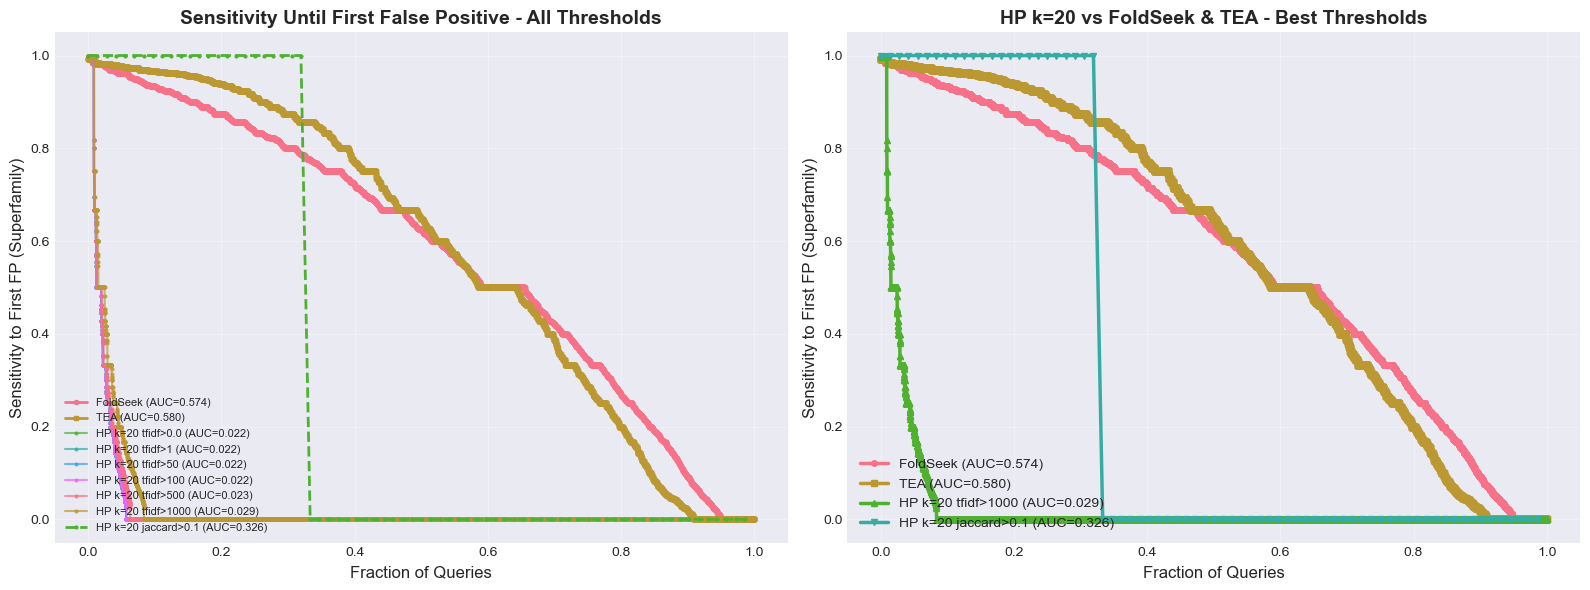

In [8]:
# Plot sensitivity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All thresholds
ax = axes[0]
ax.plot(foldseek_frac, foldseek_sens, 'o-', label=f'FoldSeek (AUC={foldseek_auc:.3f})', linewidth=2, markersize=3)
ax.plot(tea_frac, tea_sens, 's-', label=f'TEA (AUC={tea_auc:.3f})', linewidth=2, markersize=3)

for threshold, res in hp_results.items():
    if threshold == 'jaccard_0.1':
        label = f"HP k=20 jaccard>0.1 (AUC={res['auc']:.3f})"
        linestyle = '--'
        linewidth = 2
        alpha = 1.0
    else:
        label = f"HP k=20 tfidf>{threshold} (AUC={res['auc']:.3f})"
        linestyle = '-'
        linewidth = 1.5
        alpha = 0.7
    
    ax.plot(res['frac'], res['sens'], 'o-', 
            label=label,
            linewidth=linewidth, markersize=2, alpha=alpha, linestyle=linestyle)

ax.set_xlabel('Fraction of Queries', fontsize=12)
ax.set_ylabel('Sensitivity to First FP (Superfamily)', fontsize=12)
ax.set_title('Sensitivity Until First False Positive - All Thresholds', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Best thresholds vs baselines
ax = axes[1]

# Find the best TF-IDF threshold based on AUC (excluding jaccard)
tfidf_thresholds_only = {k: v for k, v in hp_results.items() if k != 'jaccard_0.1'}
best_tfidf_threshold = max(tfidf_thresholds_only.keys(), key=lambda k: hp_results[k]['auc'])
best_tfidf = hp_results[best_tfidf_threshold]
jaccard_res = hp_results['jaccard_0.1']

print(f"Best TF-IDF threshold: {best_tfidf_threshold} (AUC={best_tfidf['auc']:.3f})")
print(f"Jaccard > 0.1 (AUC={jaccard_res['auc']:.3f})")

ax.plot(foldseek_frac, foldseek_sens, 'o-', label=f'FoldSeek (AUC={foldseek_auc:.3f})', linewidth=2.5, markersize=4)
ax.plot(tea_frac, tea_sens, 's-', label=f'TEA (AUC={tea_auc:.3f})', linewidth=2.5, markersize=4)
ax.plot(best_tfidf['frac'], best_tfidf['sens'], '^-', 
        label=f"HP k=20 tfidf>{best_tfidf_threshold} (AUC={best_tfidf['auc']:.3f})",
        linewidth=2.5, markersize=4)
ax.plot(jaccard_res['frac'], jaccard_res['sens'], 'v-', 
        label=f"HP k=20 jaccard>0.1 (AUC={jaccard_res['auc']:.3f})",
        linewidth=2.5, markersize=4)

ax.set_xlabel('Fraction of Queries', fontsize=12)
ax.set_ylabel('Sensitivity to First FP (Superfamily)', fontsize=12)
ax.set_title('HP k=20 vs FoldSeek & TEA - Best Thresholds', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hp_k20_vs_foldseek_tea_sensitivity.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Store best_threshold for later cells
best_threshold = best_tfidf_threshold

## 6. Identify Unique Relationships in HP k=20

Find homology relationships (same superfamily) that HP k=20 detects but FoldSeek and TEA miss.

In [9]:
# Use the best TF-IDF threshold (from previous cell)
hp_rocx = hp_rocx_results[best_threshold]

# Get queries that successfully retrieved superfamily members before first FP
# SFAM > 0 means they found at least some superfamily members

# Queries with good performance in HP k=20
hp_good = hp_rocx.filter(pl.col('SFAM') > 0.5)
print(f"HP k=20 queries with >50% superfamily sensitivity: {len(hp_good)}")

# Queries with poor performance in FoldSeek
foldseek_poor = foldseek.filter(pl.col('SFAM') <= 0.5)
print(f"FoldSeek queries with <=50% superfamily sensitivity: {len(foldseek_poor)}")

# Queries with poor performance in TEA
tea_poor = tea_all.filter(pl.col('SFAM') <= 0.5)
print(f"TEA queries with <=50% superfamily sensitivity: {len(tea_poor)}")

# Find queries where HP k=20 succeeds but FoldSeek/TEA fail
hp_good_names = set(hp_good['NAME'].to_list())
foldseek_poor_names = set(foldseek_poor['NAME'].to_list())
tea_poor_names = set(tea_poor['NAME'].to_list())

# HP good, FoldSeek poor
hp_wins_foldseek = hp_good_names & foldseek_poor_names
print(f"\nQueries where HP k=20 succeeds but FoldSeek struggles: {len(hp_wins_foldseek)}")

# HP good, TEA poor
hp_wins_tea = hp_good_names & tea_poor_names
print(f"Queries where HP k=20 succeeds but TEA struggles: {len(hp_wins_tea)}")

# HP good, both FoldSeek and TEA poor
hp_wins_both = hp_good_names & foldseek_poor_names & tea_poor_names
print(f"Queries where HP k=20 succeeds but BOTH FoldSeek and TEA struggle: {len(hp_wins_both)}")

HP k=20 queries with >50% superfamily sensitivity: 131
FoldSeek queries with <=50% superfamily sensitivity: 2342
TEA queries with <=50% superfamily sensitivity: 2377

Queries where HP k=20 succeeds but FoldSeek struggles: 28
Queries where HP k=20 succeeds but TEA struggles: 30
Queries where HP k=20 succeeds but BOTH FoldSeek and TEA struggle: 24


In [10]:
# Create detailed comparison DataFrame
comparison = hp_rocx.select(['NAME', 'SCOP', 'SFAM', 'SFAMCNT']).rename({'SFAM': 'HP_SFAM', 'SFAMCNT': 'HP_SFAMCNT'})
comparison = comparison.join(
    foldseek.select(['NAME', 'SFAM', 'SFAMCNT']).rename({'SFAM': 'FoldSeek_SFAM', 'SFAMCNT': 'FoldSeek_SFAMCNT'}),
    on='NAME',
    how='left'
)
comparison = comparison.join(
    tea_all.select(['NAME', 'SFAM', 'SFAMCNT']).rename({'SFAM': 'TEA_SFAM', 'SFAMCNT': 'TEA_SFAMCNT'}),
    on='NAME',
    how='left'
)

# Fill nulls with 0
comparison = comparison.fill_null(0)

# Calculate advantage
comparison = comparison.with_columns([
    (pl.col('HP_SFAM') - pl.col('FoldSeek_SFAM')).alias('HP_vs_FoldSeek'),
    (pl.col('HP_SFAM') - pl.col('TEA_SFAM')).alias('HP_vs_TEA'),
])

print("\nTop 20 queries where HP k=20 outperforms FoldSeek:")
print(comparison.sort('HP_vs_FoldSeek', descending=True).head(20))

print("\nTop 20 queries where HP k=20 outperforms TEA:")
print(comparison.sort('HP_vs_TEA', descending=True).head(20))


Top 20 queries where HP k=20 outperforms FoldSeek:
shape: (20, 10)
┌─────────┬────────────┬─────────┬────────────┬───┬──────────┬────────────┬────────────┬───────────┐
│ NAME    ┆ SCOP       ┆ HP_SFAM ┆ HP_SFAMCNT ┆ … ┆ TEA_SFAM ┆ TEA_SFAMCN ┆ HP_vs_Fold ┆ HP_vs_TEA │
│ ---     ┆ ---        ┆ ---     ┆ ---        ┆   ┆ ---      ┆ T          ┆ Seek       ┆ ---       │
│ str     ┆ str        ┆ f64     ┆ i64        ┆   ┆ f64      ┆ ---        ┆ ---        ┆ f64       │
│         ┆            ┆         ┆            ┆   ┆          ┆ i64        ┆ f64        ┆           │
╞═════════╪════════════╪═════════╪════════════╪═══╪══════════╪════════════╪════════════╪═══════════╡
│ d1wqga_ ┆ d.67.3.1   ┆ 1.0     ┆ 3          ┆ … ┆ 0.0      ┆ 0          ┆ 1.0        ┆ 1.0       │
│ d7lx0l_ ┆ f.31.1.0   ┆ 1.0     ┆ 2          ┆ … ┆ 0.0      ┆ 0          ┆ 1.0        ┆ 1.0       │
│ d1tc5a1 ┆ c.110.1.1  ┆ 1.0     ┆ 3          ┆ … ┆ 0.0      ┆ 0          ┆ 1.0        ┆ 1.0       │
│ d1qwza1 ┆ b.100.1.1  

## 7. Analyze Specific Examples

In [11]:
# Pick top examples where HP k=20 significantly outperforms
top_examples = comparison.filter(
    (pl.col('HP_vs_FoldSeek') > 0.3) & 
    (pl.col('HP_vs_TEA') > 0.3)
).sort('HP_SFAM', descending=True).head(10)

print("Top examples where HP k=20 significantly outperforms both methods:")
print(top_examples)

# For each example, show what HP k=20 found
for row in top_examples.iter_rows(named=True):
    query_name = row['NAME']
    print(f"\n{'='*80}")
    print(f"Query: {query_name} - {row['SCOP']}")
    print(f"HP k=20 SFAM sensitivity: {row['HP_SFAM']:.3f} (found {row['HP_SFAMCNT']} members)")
    print(f"FoldSeek SFAM sensitivity: {row['FoldSeek_SFAM']:.3f}")
    print(f"TEA SFAM sensitivity: {row['TEA_SFAM']:.3f}")
    
    # Show actual hits from HP k=20
    query_hits = hp_k20.filter(
        (pl.col('query_name').str.contains(query_name)) &
        (pl.col('tfidf') > best_threshold) &
        (pl.col('superfamily_match'))
    ).sort('tfidf', descending=True).head(10)
    
    print(f"\nTop superfamily hits found by HP k=20:")
    print(query_hits.select(['target_name', 'tfidf', 'jaccard', 'max_containment']).head(10))

Top examples where HP k=20 significantly outperforms both methods:
shape: (10, 10)
┌─────────┬───────────┬─────────┬────────────┬───┬──────────┬─────────────┬────────────┬───────────┐
│ NAME    ┆ SCOP      ┆ HP_SFAM ┆ HP_SFAMCNT ┆ … ┆ TEA_SFAM ┆ TEA_SFAMCNT ┆ HP_vs_Fold ┆ HP_vs_TEA │
│ ---     ┆ ---       ┆ ---     ┆ ---        ┆   ┆ ---      ┆ ---         ┆ Seek       ┆ ---       │
│ str     ┆ str       ┆ f64     ┆ i64        ┆   ┆ f64      ┆ i64         ┆ ---        ┆ f64       │
│         ┆           ┆         ┆            ┆   ┆          ┆             ┆ f64        ┆           │
╞═════════╪═══════════╪═════════╪════════════╪═══╪══════════╪═════════════╪════════════╪═══════════╡
│ d1wqga_ ┆ d.67.3.1  ┆ 1.0     ┆ 3          ┆ … ┆ 0.0      ┆ 0           ┆ 1.0        ┆ 1.0       │
│ d7lx0l_ ┆ f.31.1.0  ┆ 1.0     ┆ 2          ┆ … ┆ 0.0      ┆ 0           ┆ 1.0        ┆ 1.0       │
│ d1tc5a1 ┆ c.110.1.1 ┆ 1.0     ┆ 3          ┆ … ┆ 0.0      ┆ 0           ┆ 1.0        ┆ 1.0       │
│ d1glaf

## 8. Summary Statistics

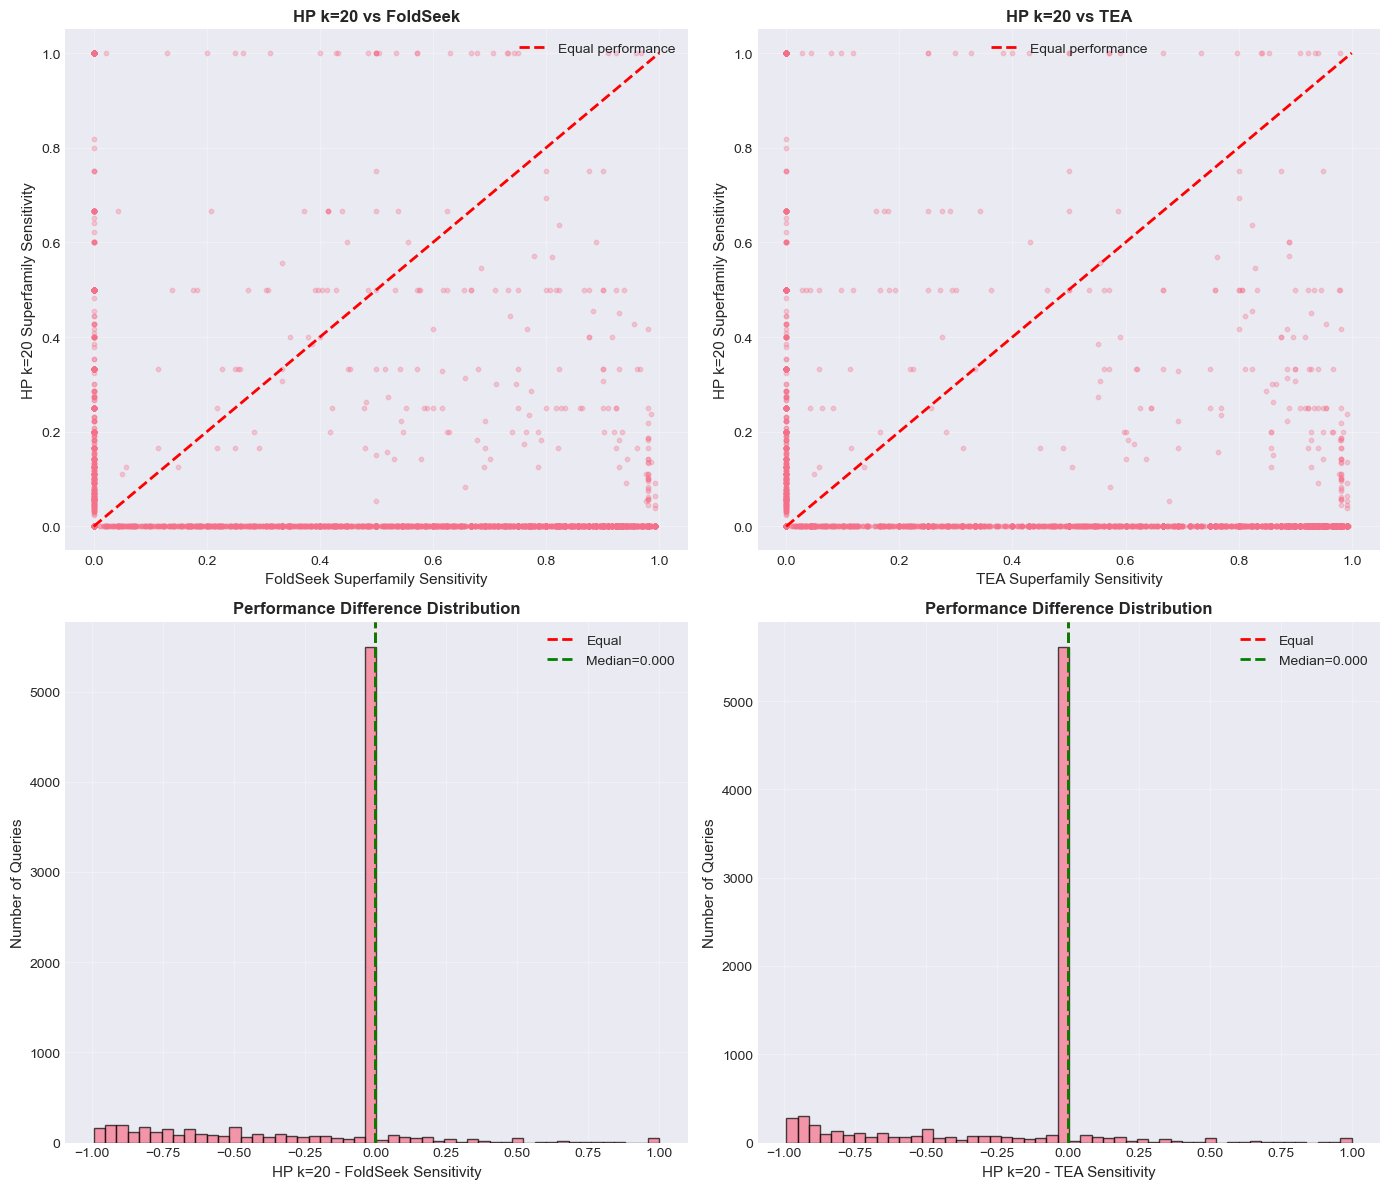


Performance Difference Statistics:
HP k=20 vs FoldSeek:
  Median difference: 0.0000
  Mean difference: -0.1609
  HP wins (>0): 561 (6.6%)
  HP significantly better (>0.2): 270

HP k=20 vs TEA:
  Median difference: 0.0000
  Mean difference: -0.1574
  HP wins (>0): 563 (6.6%)
  HP significantly better (>0.2): 276


In [12]:
# Create summary plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter - HP vs FoldSeek
ax = axes[0, 0]
ax.scatter(comparison['FoldSeek_SFAM'], comparison['HP_SFAM'], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', label='Equal performance', linewidth=2)
ax.set_xlabel('FoldSeek Superfamily Sensitivity', fontsize=11)
ax.set_ylabel('HP k=20 Superfamily Sensitivity', fontsize=11)
ax.set_title('HP k=20 vs FoldSeek', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Scatter - HP vs TEA
ax = axes[0, 1]
ax.scatter(comparison['TEA_SFAM'], comparison['HP_SFAM'], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', label='Equal performance', linewidth=2)
ax.set_xlabel('TEA Superfamily Sensitivity', fontsize=11)
ax.set_ylabel('HP k=20 Superfamily Sensitivity', fontsize=11)
ax.set_title('HP k=20 vs TEA', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Histogram of differences - HP vs FoldSeek
ax = axes[1, 0]
diff_foldseek = comparison['HP_vs_FoldSeek'].to_numpy()
ax.hist(diff_foldseek, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Equal')
ax.axvline(np.median(diff_foldseek), color='green', linestyle='--', linewidth=2, label=f'Median={np.median(diff_foldseek):.3f}')
ax.set_xlabel('HP k=20 - FoldSeek Sensitivity', fontsize=11)
ax.set_ylabel('Number of Queries', fontsize=11)
ax.set_title('Performance Difference Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Histogram of differences - HP vs TEA
ax = axes[1, 1]
diff_tea = comparison['HP_vs_TEA'].to_numpy()
ax.hist(diff_tea, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Equal')
ax.axvline(np.median(diff_tea), color='green', linestyle='--', linewidth=2, label=f'Median={np.median(diff_tea):.3f}')
ax.set_xlabel('HP k=20 - TEA Sensitivity', fontsize=11)
ax.set_ylabel('Number of Queries', fontsize=11)
ax.set_title('Performance Difference Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hp_k20_comparison_detailed.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print statistics
print("\nPerformance Difference Statistics:")
print(f"HP k=20 vs FoldSeek:")
print(f"  Median difference: {np.median(diff_foldseek):.4f}")
print(f"  Mean difference: {np.mean(diff_foldseek):.4f}")
print(f"  HP wins (>0): {np.sum(diff_foldseek > 0)} ({np.sum(diff_foldseek > 0)/len(diff_foldseek)*100:.1f}%)")
print(f"  HP significantly better (>0.2): {np.sum(diff_foldseek > 0.2)}")

print(f"\nHP k=20 vs TEA:")
print(f"  Median difference: {np.median(diff_tea):.4f}")
print(f"  Mean difference: {np.mean(diff_tea):.4f}")
print(f"  HP wins (>0): {np.sum(diff_tea > 0)} ({np.sum(diff_tea > 0)/len(diff_tea)*100:.1f}%)")
print(f"  HP significantly better (>0.2): {np.sum(diff_tea > 0.2)}")

## 9. Save Results

In [13]:
# Save comparison table
comparison.write_parquet('hp_k20_vs_foldseek_tea_comparison.parquet')
comparison.write_csv('hp_k20_vs_foldseek_tea_comparison.csv')

# Save unique HP k=20 wins
hp_unique = comparison.filter(
    (pl.col('HP_SFAM') > 0.5) &
    ((pl.col('FoldSeek_SFAM') <= 0.5) | (pl.col('TEA_SFAM') <= 0.5))
).sort('HP_SFAM', descending=True)

hp_unique.write_csv('hp_k20_unique_wins.csv')
print(f"\nSaved {len(hp_unique)} unique HP k=20 wins to hp_k20_unique_wins.csv")


Saved 109 unique HP k=20 wins to hp_k20_unique_wins.csv
